# FlameIQ Refill Prediction — Data Exploration

## Objective

This notebook explores the datasets available for the FlameIQ refill prediction proof of concept and assesses their suitability for machine-learning model development.

The analysis focuses on household LPG users because the FlameIQ MVP is household-first. It also identifies fields that can safely be used for prediction and fields that would create target leakage.

Because longitudinal production refill history was not available before the hackathon, the raw analytics datasets are used for product and user understanding, while a separate labelled synthetic refill-cycle dataset is used for the prediction proof of concept.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
BASE_DIR = Path.cwd().resolve().parents[0]

if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

users = pd.read_csv(RAW_DIR / "users_dim.csv")
orders = pd.read_csv(RAW_DIR / "orders_fact.csv")
vendors = pd.read_csv(RAW_DIR / "vendors_dim.csv")

refill_cycles = pd.read_csv(
    PROCESSED_DIR / "refill_cycles_model.csv"
)

print("Users:", users.shape)
print("Orders:", orders.shape)
print("Vendors:", vendors.shape)
print("Refill cycles:", refill_cycles.shape)

Users: (1500, 10)
Orders: (10000, 31)
Vendors: (50, 8)
Refill cycles: (8368, 16)


## Dataset Overview

The supplied FlameIQ analytics data consists of three main tables:

- `users_dim.csv` - customer profile and segmentation information.
- `orders_fact.csv` - transaction, delivery and product analytics information.
- `vendors_dim.csv` - vendor profile and operational information.

These datasets are useful for understanding FlameIQ users and marketplace activity. However, the order dataset contains several fields that represent prediction outputs or post-outcome information rather than valid prediction inputs.

Examples include:

- `actual_consumption_cycle_days`
- `days_remaining`
- `predicted_refill_date`
- `current_gas_level_pct`
- `ai_prediction_confidence_pct`
- `prediction_error_days`

Using these as model features would create target leakage. They are therefore excluded from the refill prediction feature set.

In [3]:
print("USER SEGMENTS")
display(users["segment"].value_counts())

print("\nCYLINDER SIZES")
display(users["cylinder_size_kg"].value_counts().sort_index())

print("\nSEGMENT BY CYLINDER SIZE")
display(
    pd.crosstab(
        users["segment"],
        users["cylinder_size_kg"]
    )
)

USER SEGMENTS


segment
Household    1257
Business      243
Name: count, dtype: int64


CYLINDER SIZES


cylinder_size_kg
6.0     461
12.5    796
25.0    149
50.0     94
Name: count, dtype: int64


SEGMENT BY CYLINDER SIZE


cylinder_size_kg,6.0,12.5,25.0,50.0
segment,,,,
Business,0,0,149,94
Household,461,796,0,0


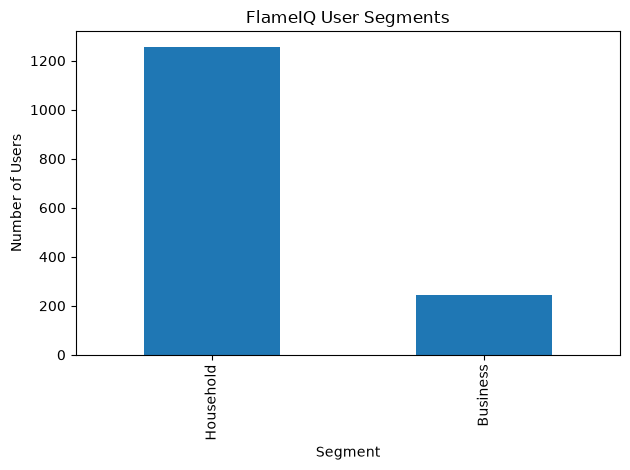

In [4]:
users["segment"].value_counts().plot(
    kind="bar",
    title="FlameIQ User Segments"
)

plt.xlabel("Segment")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

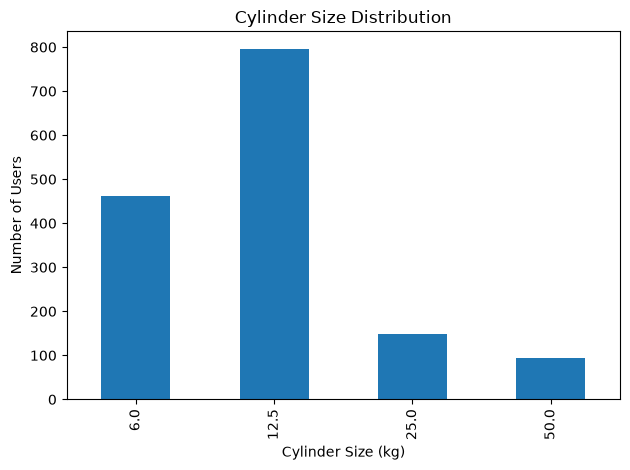

In [5]:
users["cylinder_size_kg"].value_counts().sort_index().plot(
    kind="bar",
    title="Cylinder Size Distribution"
)

plt.xlabel("Cylinder Size (kg)")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

## Household-First Modelling Scope

The modelling proof of concept focuses on household users.

The available user data shows that household and business customers have materially different cylinder-size profiles. Household users primarily use 6 kg and 12.5 kg cylinders, while business users use larger 25 kg and 50 kg cylinders.

Combining both groups in a single prototype model could allow the model to use cylinder size as a proxy for customer segment rather than learning household consumption behaviour properly.

The household-only approach therefore aligns with the FlameIQ MVP scope and reduces avoidable confounding.

In [6]:
refill_cycles.head()

,user_id,refill_cycle_id,refill_date,cylinder_size_kg,refill_quantity_kg,household_size,meals_per_day,cooking_days_per_week,lpg_primary_fuel,usage_change,festive_period,refill_month,previous_cycle_days,average_previous_cycle_days,number_previous_cycles,actual_cycle_days
0,USR_20000,USR_20000_C01,2025-03-06,12.5,11.52,6,3,6,0,normal,0,3,NaN,NaN,0,40
1,USR_20000,USR_20000_C02,2025-04-15,12.5,9.37,6,3,6,0,normal,0,4,40.0,40.000000,1,34
2,USR_20000,USR_20000_C03,2025-05-19,12.5,11.94,6,3,6,0,normal,0,5,34.0,37.000000,2,36
3,USR_20000,USR_20000_C04,2025-06-24,12.5,9.65,6,3,6,0,more,0,6,36.0,36.666667,3,28
4,USR_20000,USR_20000_C05,2025-07-22,12.5,12.50,6,3,6,0,less,0,7,28.0,34.500000,4,55


In [7]:
refill_cycles.info()

<class 'pandas.DataFrame'>
RangeIndex: 8368 entries, 0 to 8367
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      8368 non-null   str    
 1   refill_cycle_id              8368 non-null   str    
 2   refill_date                  8368 non-null   str    
 3   cylinder_size_kg             8368 non-null   float64
 4   refill_quantity_kg           8368 non-null   float64
 5   household_size               8368 non-null   int64  
 6   meals_per_day                8368 non-null   int64  
 7   cooking_days_per_week        8368 non-null   int64  
 8   lpg_primary_fuel             8368 non-null   int64  
 9   usage_change                 8368 non-null   str    
 10  festive_period               8368 non-null   int64  
 11  refill_month                 8368 non-null   int64  
 12  previous_cycle_days          7111 non-null   float64
 13  average_previous_cycle_days  

In [8]:
refill_cycles["actual_cycle_days"].describe()

count    8368.000000
mean       30.961401
std        13.004318
min         6.000000
25%        21.000000
50%        29.000000
75%        39.000000
max        75.000000
Name: actual_cycle_days, dtype: float64

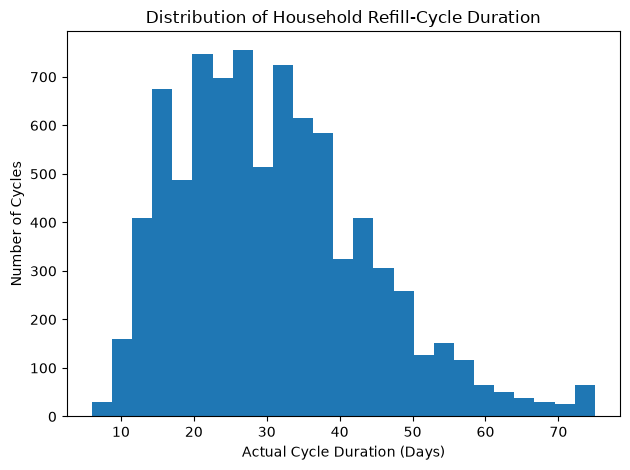

In [9]:
plt.hist(
    refill_cycles["actual_cycle_days"],
    bins=25
)

plt.title("Distribution of Household Refill-Cycle Duration")
plt.xlabel("Actual Cycle Duration (Days)")
plt.ylabel("Number of Cycles")
plt.tight_layout()
plt.show()

In [10]:
cold_start = refill_cycles[
    refill_cycles["number_previous_cycles"] == 0
]

returning = refill_cycles[
    refill_cycles["number_previous_cycles"] > 0
]

print("Cold-start cycles:", len(cold_start))
print("Returning-user cycles:", len(returning))

Cold-start cycles: 1257
Returning-user cycles: 7111


## Initial Findings

The exploratory analysis supports a two-pathway prediction architecture.

### Cold-start users

A new user has no historical refill cycle. Their first estimate must therefore rely on household and cooking characteristics such as cylinder size, refill quantity, household size, meals cooked per day, cooking days per week and whether LPG is the primary cooking fuel.

### Returning users

Once a customer has completed previous refill cycles, historical refill duration becomes available. These features provide an additional source of personalised behavioural information.

This leads to two modelling pathways:

1. A cold-start model for first-time users.
2. A personalised model for users with refill history.

The next notebook validates the synthetic refill-cycle dataset before model experimentation.